## Use Heart Disease [Dataset](https://github.com/cksajil/DSAIRP25/blob/main/datasets/heart_disease.csv) and answer the following questions

## 1. Find the top 5 important features to the target column

In [57]:
import pandas as pd
df=pd.read_csv("P:\\Downloads\\heart_disease.csv")
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [58]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

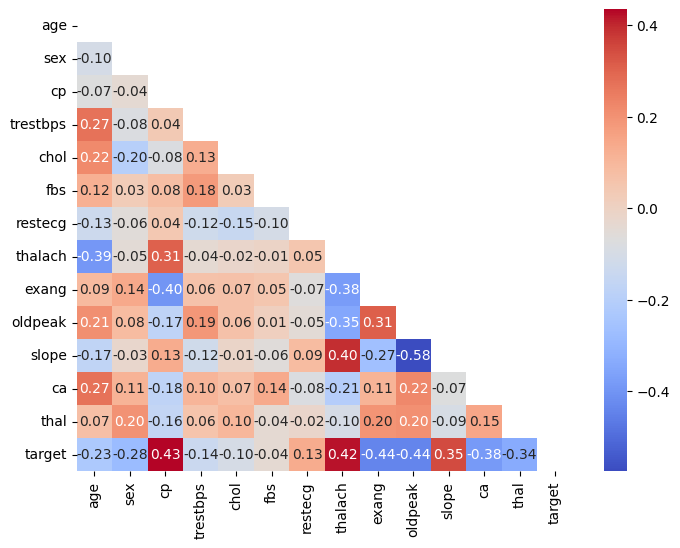

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
corr=df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


In [60]:
df.shape

(1025, 14)

In [61]:
from sklearn.ensemble import RandomForestClassifier

X=df.drop(columns=['target'])
y=df['target']

model= RandomForestClassifier(n_estimators=500,random_state=42)
model.fit(X,y)

imp=pd.Series(model.feature_importances_, index=X.columns)

top5=imp.sort_values(ascending=False).head(5)
print(top5)

cp         0.137241
ca         0.124154
thalach    0.116048
oldpeak    0.111410
thal       0.100678
dtype: float64


## 2. Perform Box-Cox Transformations to relevant features

In [62]:
skew=df.skew(numeric_only=True).abs().sort_values(ascending=False)
print(skew)

fbs         1.971339
ca          1.261189
oldpeak     1.210899
chol        1.074073
sex         0.851449
trestbps    0.739768
exang       0.692655
cp          0.529455
thal        0.524390
thalach     0.513777
slope       0.479134
age         0.248866
restecg     0.180440
target      0.052778
dtype: float64


In [63]:
df.columns
#trestbps, chol,fbs,oldpeak,ca,exang

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [64]:
df.skew()

age        -0.248866
sex        -0.851449
cp          0.529455
trestbps    0.739768
chol        1.074073
fbs         1.971339
restecg     0.180440
thalach    -0.513777
exang       0.692655
oldpeak     1.210899
slope      -0.479134
ca          1.261189
thal       -0.524390
target     -0.052778
dtype: float64

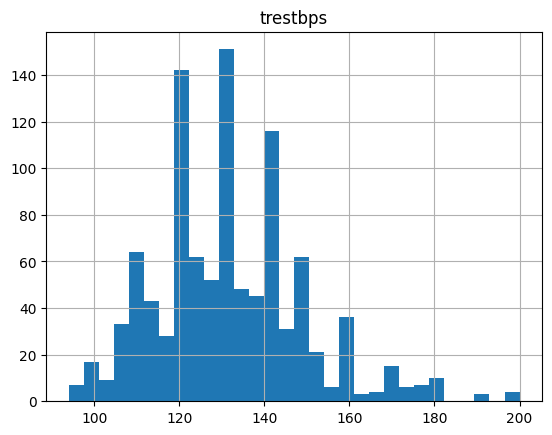

In [65]:
import matplotlib.pyplot as plt

df['trestbps'].hist(bins=30)
plt.title('trestbps')
plt.show()

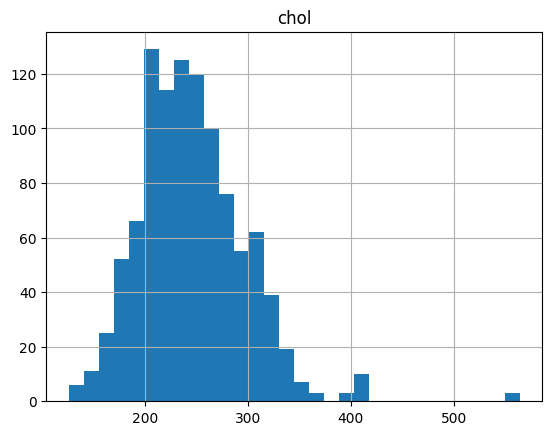

In [66]:
df['chol'].hist(bins=30)
plt.title('chol')
plt.show()

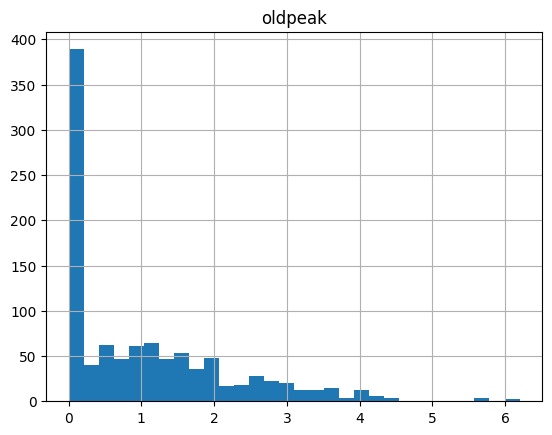

In [67]:
df['oldpeak'].hist(bins=30)
plt.title('oldpeak')
plt.show()

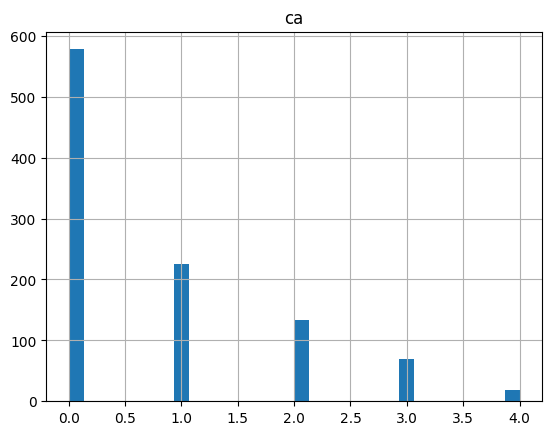

In [68]:
df['ca'].hist(bins=30)
plt.title('ca')
plt.show()

-0.7397140640815991 -0.10086495050207854


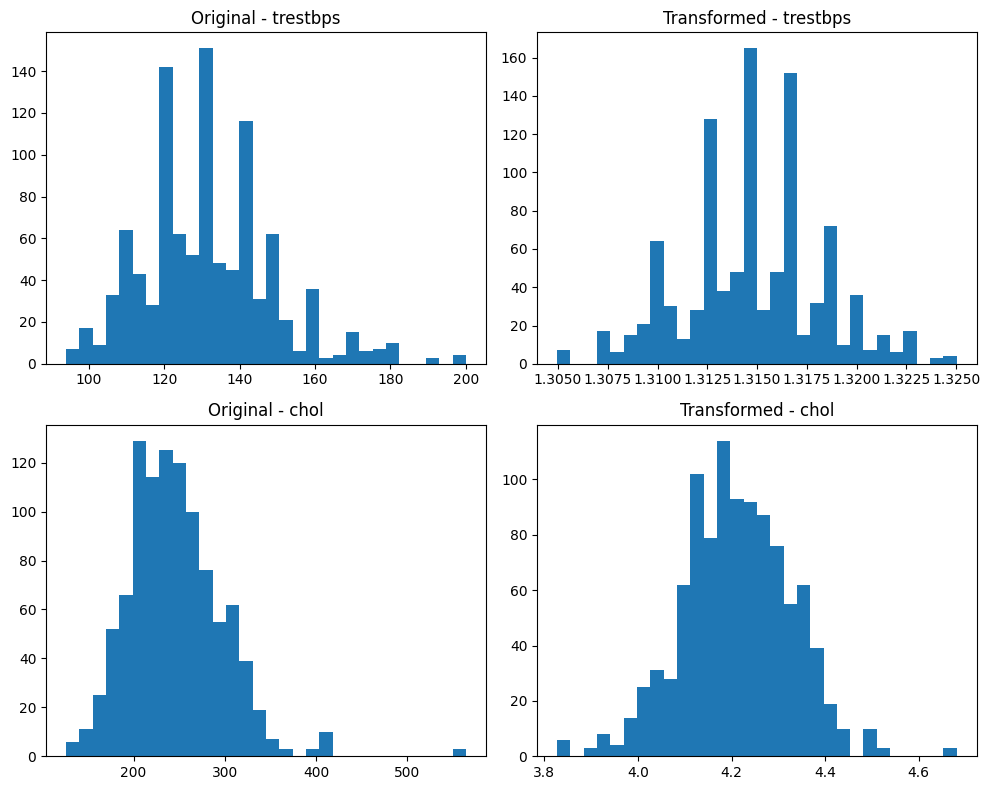

In [69]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df['trestbps_bc'], lambda1 = stats.boxcox(df['trestbps'])
df['chol_bc'], lambda2 = stats.boxcox(df['chol'])

print(lambda1, lambda2)

plt.figure(figsize=(10, 8))

# 2x2 grid
plt.subplot(2, 2, 1)
plt.hist(df['trestbps'], bins=30)
plt.title('Original - trestbps')

plt.subplot(2, 2, 2)
plt.hist(df['trestbps_bc'], bins=30)
plt.title('Transformed - trestbps')

plt.subplot(2, 2, 3)
plt.hist(df['chol'], bins=30)
plt.title('Original - chol')

plt.subplot(2, 2, 4)
plt.hist(df['chol_bc'], bins=30)
plt.title('Transformed - chol')

plt.tight_layout()
plt.show()

## 3. Perform Feature Binning to Age Column and add it as a new column to the dataset

In [70]:
df['age_bin'] = pd.qcut(df['age'], q=5, labels=False)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,trestbps_bc,chol_bc,age_bin
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,1.313870,4.138422,1
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,1.316926,4.113095,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,1.317822,4.022191,4
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,1.318334,4.113095,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,1.316552,4.325814,3


## 4. Find the most orthogonal feature to the 'chol' feature

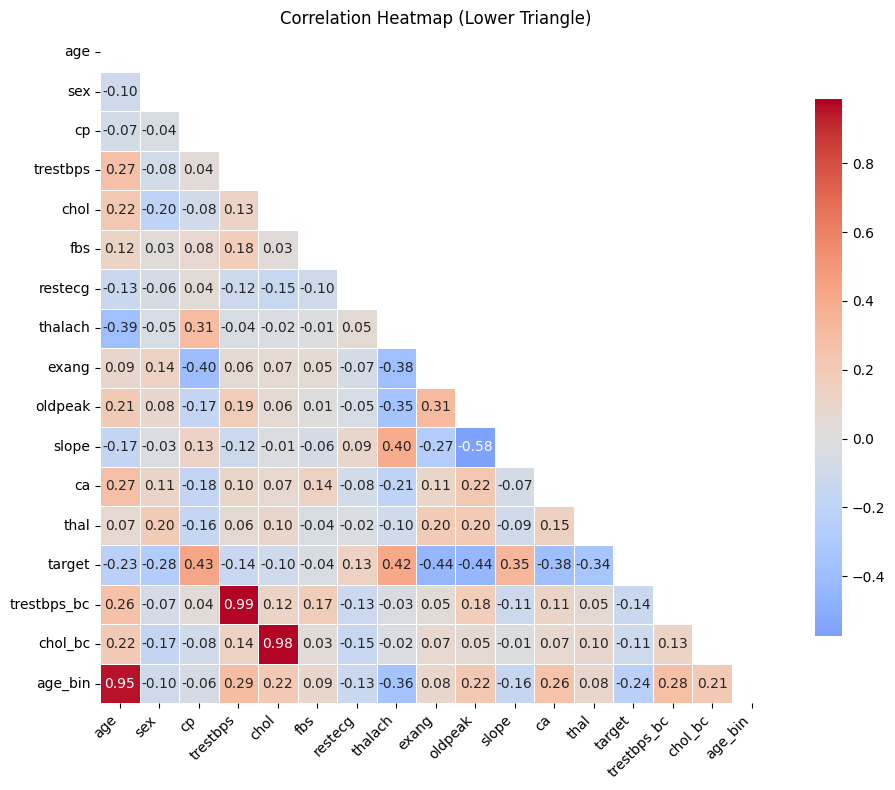

In [71]:
import seaborn as sns
import numpy as np
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,        # show values
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()


In [72]:
def most_orthogonal_corr(df, j):
    corr = df.corr(numeric_only=True)[j].abs()
    corr = corr.drop(j)
    return corr.idxmin(), corr
best, scores = most_orthogonal_corr(df, 'chol')

print(best,scores)

slope age            0.219823
sex            0.198258
cp             0.081641
trestbps       0.127977
fbs            0.026917
restecg        0.147410
thalach        0.021772
exang          0.067382
oldpeak        0.064880
slope          0.014248
ca             0.074259
thal           0.100244
target         0.099966
trestbps_bc    0.124643
chol_bc        0.981284
age_bin        0.215094
Name: chol, dtype: float64


'slope' is most orthogonal feature to 'chol'